# 1. Purpose and application logic

N24 asks whether the frozen hidden realised--implied state contains incremental forward information about the next-period ordinary-model log forecast error. It then translates this fixed information set into a deliberately low-capacity long / short / flat synthetic-straddle policy. DEVELOPMENT selects statistical hyperparameters; VALIDATION evaluates forward information and selects one policy; TEST is not used.

$$
H_t+S_{t+1}\rightarrow\widehat C_{t+1}\rightarrow\widehat G_{t+1}\rightarrow a_t\rightarrow\Pi_{t+1}.
$$

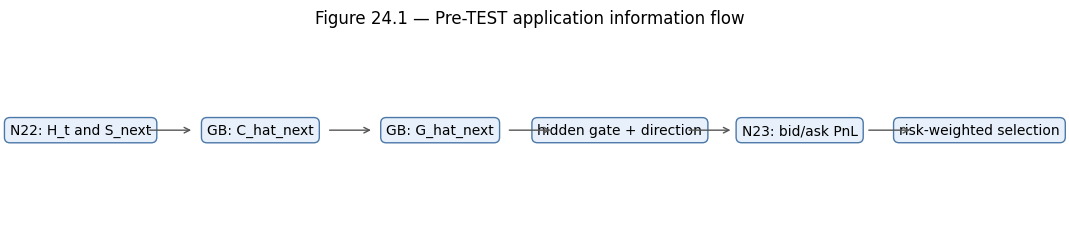

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

# Record any notebook-runtime warnings while preserving their normal display.
execution_warning_log = []
original_showwarning = warnings.showwarning

def record_notebook_warning(message, category, filename, lineno, file=None, line=None):
    execution_warning_log.append((str(message), category.__name__, filename, lineno))
    original_showwarning(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = record_notebook_warning

PROJECT_DIR = Path.cwd().resolve()
PROCESSED = PROJECT_DIR / "Data" / "processed"
FIGURES = PROJECT_DIR / "figures"
UNLOCK_TEST = False
assert UNLOCK_TEST is False
N_ESTIMATORS = 100
LEARNING_RATE = 0.05
LOSS = "squared_error"
RANDOM_STATE = 24
GRID = [(1, 20), (1, 40), (2, 20), (2, 40)]
TSCV_SPLITS = 4
BLOCK_LENGTH = 5
BOOTSTRAP_REPS = 5000
BOOTSTRAP_SEED = 24
MINIMUM_TRADES = 4

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis("off")
labels = ["N22: H_t and S_next", "GB: C_hat_next", "GB: G_hat_next", "hidden gate + direction", "N23: bid/ask PnL", "risk-weighted selection"]
positions = np.linspace(.06, .94, len(labels))
for position, label in zip(positions, labels):
    ax.text(position, .5, label, ha="center", va="center", bbox={"boxstyle": "round,pad=.4", "facecolor": "#e8f1fb", "edgecolor": "#4c78a8"})
for left, right in zip(positions[:-1], positions[1:]):
    ax.annotate("", xy=(right - .065, .5), xytext=(left + .065, .5), arrowprops={"arrowstyle": "->", "color": "#555555"})
ax.set_title("Figure 24.1 — Pre-TEST application information flow")
fig.tight_layout()
fig.savefig(FIGURES / "24_figure_application_information_flow.png", dpi=180)
plt.show()


# 2. Frozen inputs and TEST embargo

N22 supplies the causal state, frozen ordinary forecast, and locked targets. N23 supplies only mechanically constructed synthetic option outcomes. TEST rows are retained only to prove the embargo; they never enter fitting, tuning, validation evaluation, bootstrap analysis, policy selection, or refitting.

In [2]:
n22_path = PROCESSED / "22_application_causal_state_panel.csv"
n23_path = PROCESSED / "23_application_option_pnl_panel.csv"
n22 = pd.read_csv(n22_path, parse_dates=["model_day", "next_model_day"])
n23 = pd.read_csv(n23_path, parse_dates=["model_day", "next_model_day"])
assert n22.model_day.is_unique and n23.model_day.is_unique

test_locked_audit = n22.loc[n22.application_stage.eq("TEST")].copy()
test_pnl_audit = n23.loc[n23.application_stage.eq("TEST")].copy()
assert test_locked_audit["G_next"].isna().all()
assert test_locked_audit["C_next"].isna().all()
assert test_pnl_audit["terminal_spot"].isna().all()
assert test_pnl_audit[["long_pnl_bidask", "short_pnl_bidask"]].isna().all().all()
assert test_pnl_audit["pnl_unlocked"].eq(False).all()

source_table = pd.DataFrame([
    ("22_application_causal_state_panel.csv", "state, ordinary forecast, locked target", "model_day, S_next, D, Z_R, Z_I_prev, C_next", "AUTHORITATIVE"),
    ("23_application_option_pnl_panel.csv", "mechanical synthetic option outcome", "contract_complete, bid/ask PnL, entry midpoint", "AUTHORITATIVE"),
], columns=["source", "role", "fields used", "status"])
display(source_table)

,source,role,fields used,status
0,22_application_causal_state_panel.csv,"state, ordinary forecast, locked target","model_day, S_next, D, Z_R, Z_I_prev, C_next",AUTHORITATIVE
1,23_application_option_pnl_panel.csv,mechanical synthetic option outcome,"contract_complete, bid/ask PnL, entry midpoint",AUTHORITATIVE


# 3. Next-period ordinary-model log forecast error

N22 defines the realised-versus-implied gap and ordinary forward state:

$$G_{t+1}=\log\left(\frac{R_{t+1}}{I_t}\right),\qquad S_{t+1}=\operatorname{median}_m\log\left(\frac{I_t}{\widehat R_{m,t+1}}\right).$$

The frozen ordinary prediction is \(\widehat G_{t+1}^{ordinary}=-S_{t+1}\). N24 forecasts its next-period log forecast error, also the correction required to the ordinary system:

$$C_{t+1}=G_{t+1}+S_{t+1}=\operatorname{median}_m\log\left(\frac{R_{t+1}}{\widehat R_{m,t+1}}\right).$$

# 4. Information set and common statistical eligibility

The deliberately low-dimensional feature families are \(X^S=\{S_{t+1}\}\), \(X^H=\{D_t,Z_t^R,Z_{t-1}^I\}\), and their union. The primary statistical sample excludes frozen known-primary-event pairs: the purpose is hidden/ordinary-system departures, while ordinary `NONE` states remain in the dense learner.

In [3]:
feature_sets = {
    "S_ONLY": ["S_next"],
    "HIDDEN_ONLY": ["D", "Z_R", "Z_I_prev"],
    "COMBINED": ["S_next", "D", "Z_R", "Z_I_prev"],
}
information_table = pd.DataFrame([
    ("S_next", "ordinary forward state", "known by end of model day t", "ordinary baseline feature", True),
    ("D", "cross-channel realised-implied disagreement", "known by end of model day t", "hidden-state feature", True),
    ("Z_R", "realised-channel abnormality", "known by end of model day t", "hidden-state feature", True),
    ("Z_I_prev", "prior implied-channel abnormality", "known by end of model day t", "hidden-state feature", True),
], columns=["variable", "meaning", "timing", "role", "known_at_t"])
display(information_table)

finite_columns = ["S_next", "D", "Z_R", "Z_I_prev", "C_next"]
state_is_complete = n22[finite_columns].apply(np.isfinite).all(axis=1)
common_mask = (
    n22.application_stage.isin(["DEVELOPMENT", "VALIDATION"])
    & n22.state_scored.eq(True)
    & n22.feature_complete.eq(True)
    & n22.target_complete.eq(True)
    & ~n22.is_known_primary_event_pair.eq(True)
    & state_is_complete
)
common_sample = n22.loc[common_mask].sort_values("model_day").copy()
development_data = common_sample.loc[common_sample.application_stage.eq("DEVELOPMENT")].copy()
validation_data = common_sample.loc[common_sample.application_stage.eq("VALIDATION")].copy()
assert development_data.model_day.is_monotonic_increasing
assert validation_data.model_day.is_monotonic_increasing
assert not development_data.application_stage.eq("TEST").any()
assert not validation_data.application_stage.eq("TEST").any()
coverage_table = pd.DataFrame([
    ("DEVELOPMENT", len(development_data), int(n22.loc[n22.application_stage.eq("DEVELOPMENT"), "is_known_primary_event_pair"].sum())),
    ("VALIDATION", len(validation_data), int(n22.loc[n22.application_stage.eq("VALIDATION"), "is_known_primary_event_pair"].sum())),
], columns=["stage", "common statistical rows", "known-primary exclusions"])
display(coverage_table)

known_event_lookup = n22[["model_day", "is_known_primary_event_pair"]].rename(
    columns={"model_day": "next_model_day", "is_known_primary_event_pair": "is_known_primary_event_next"}
)
primary_rows_audit = n22.loc[
    n22.application_stage.isin(["DEVELOPMENT", "VALIDATION"])
    & n22[finite_columns].apply(np.isfinite).all(axis=1)
    & n22.state_scored.eq(True)
    & n22.feature_complete.eq(True)
    & n22.target_complete.eq(True)
].merge(known_event_lookup, on="next_model_day", how="left", validate="many_to_one")
primary_rows_audit["is_known_primary_event_next"] = primary_rows_audit["is_known_primary_event_next"].fillna(False).astype(bool)
known_event_audit_rows = []
for stage, stage_frame in primary_rows_audit.groupby("application_stage", sort=False):
    known_at_t = stage_frame["is_known_primary_event_pair"].astype(bool)
    known_at_next = stage_frame["is_known_primary_event_next"].astype(bool)
    known_at_t_only = known_at_t & ~known_at_next
    known_at_next_only = ~known_at_t & known_at_next
    known_at_both = known_at_t & known_at_next
    known_at_either = known_at_t | known_at_next
    known_at_neither = ~known_at_t & ~known_at_next
    known_event_audit_rows.append({
        "application_stage": stage,
        "total_common_rows_before_known_event_exclusion": len(stage_frame),
        "known_at_t_only": int(known_at_t_only.sum()),
        "known_at_t_plus_1_only": int(known_at_next_only.sum()),
        "known_at_both": int(known_at_both.sum()),
        "known_at_either": int(known_at_either.sum()),
        "known_at_neither": int(known_at_neither.sum()),
        "pct_t_plus_1_known": float(known_at_next.mean()),
    })
known_event_target_day_audit = pd.DataFrame(known_event_audit_rows)
assert (known_event_target_day_audit.known_at_either == known_event_target_day_audit.total_common_rows_before_known_event_exclusion - known_event_target_day_audit.known_at_neither).all()
display(known_event_target_day_audit)


,variable,meaning,timing,role,known_at_t
0,S_next,ordinary forward state,known by end of model day t,ordinary baseline feature,True
1,D,cross-channel realised-implied disagreement,known by end of model day t,hidden-state feature,True
2,Z_R,realised-channel abnormality,known by end of model day t,hidden-state feature,True
3,Z_I_prev,prior implied-channel abnormality,known by end of model day t,hidden-state feature,True


,stage,common statistical rows,known-primary exclusions
0,DEVELOPMENT,579,510
1,VALIDATION,657,494


,application_stage,total_common_rows_before_known_event_exclusion,known_at_t_only,known_at_t_plus_1_only,known_at_both,known_at_either,known_at_neither,pct_t_plus_1_known
0,DEVELOPMENT,1003,160,162,264,586,417,0.424726
1,VALIDATION,1124,173,179,294,646,478,0.420819


# 5. Non-parametric model design

The sole learner is `GradientBoostingRegressor`. The fixed, low-capacity grid has 100 trees, learning rate 0.05, squared-error loss, full subsampling, and seed 24. Only maximum depth \(\{1,2\}\) and minimum leaf size \(\{20,40\}\) vary. PnL never chooses a model, feature set, or hyperparameter.

In [4]:
def make_model(max_depth, min_samples_leaf):
    return GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        loss=LOSS,
        subsample=1.0,
        random_state=RANDOM_STATE,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
    )

def rmse(actual, predicted):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2)))

def mae(actual, predicted):
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(predicted))))

cv_rows = []
splitter = TimeSeriesSplit(n_splits=TSCV_SPLITS)
for family, features in feature_sets.items():
    X = development_data[features]
    y = development_data["C_next"]
    for max_depth, min_leaf in GRID:
        fold_rmses = []
        fold_maes = []
        for train_index, fold_index in splitter.split(X):
            model = make_model(max_depth, min_leaf)
            model.fit(X.iloc[train_index], y.iloc[train_index])
            prediction = model.predict(X.iloc[fold_index])
            fold_rmses.append(rmse(y.iloc[fold_index], prediction))
            fold_maes.append(mae(y.iloc[fold_index], prediction))
        cv_rows.append({
            "feature_family": family, "max_depth": max_depth, "min_samples_leaf": min_leaf,
            "fold_rmses": json.dumps(fold_rmses), "mean_rmse": np.mean(fold_rmses),
            "mean_mae": np.mean(fold_maes),
        })
cv_results = pd.DataFrame(cv_rows)
selected_params = {}
for family in feature_sets:
    candidates = cv_results.loc[cv_results.feature_family.eq(family)].copy()
    candidates = candidates.sort_values(["mean_rmse", "max_depth", "min_samples_leaf"], ascending=[True, True, False])
    selected_params[family] = (int(candidates.iloc[0].max_depth), int(candidates.iloc[0].min_samples_leaf))
cv_results["selected"] = cv_results.apply(lambda row: (int(row.max_depth), int(row.min_samples_leaf)) == selected_params[row.feature_family], axis=1)
display(cv_results.round({"mean_rmse": 5, "mean_mae": 5}))
assert cv_results.groupby("feature_family").size().eq(4).all()

,feature_family,max_depth,min_samples_leaf,fold_rmses,mean_rmse,mean_mae,selected
0,S_ONLY,1,20,"[0.7467859106840006, 0.6417828220946389, 0.712...",0.70346,0.52932,True
1,S_ONLY,1,40,"[0.7561231706951774, 0.6419792833085136, 0.711...",0.70568,0.53195,False
2,S_ONLY,2,20,"[0.7485551025694726, 0.6439868449376308, 0.714...",0.70933,0.53558,False
3,S_ONLY,2,40,"[0.7561231706951774, 0.6410446941314389, 0.708...",0.70813,0.53355,False
4,HIDDEN_ONLY,1,20,"[0.7481117479824718, 0.6530560548907828, 0.715...",0.71345,0.53773,True
5,HIDDEN_ONLY,1,40,"[0.74934813536145, 0.6534690600748972, 0.71316...",0.71439,0.53928,False
6,HIDDEN_ONLY,2,20,"[0.7637820240587584, 0.6709412678204041, 0.725...",0.72545,0.54557,False
7,HIDDEN_ONLY,2,40,"[0.74934813536145, 0.6607744071807164, 0.72615...",0.72044,0.54078,False
8,COMBINED,1,20,"[0.7292830567354358, 0.6432971883029096, 0.705...",0.69827,0.52629,True
9,COMBINED,1,40,"[0.730923157295023, 0.6430954707405134, 0.7049...",0.69866,0.52674,False


# 6. DEVELOPMENT chronological model selection

The four pre-specified Gradient Boosting configurations are assessed using chronological DEVELOPMENT folds only.


# 7. VALIDATION incremental predictive information

The frozen DEVELOPMENT-selected configurations are compared on the untouched VALIDATION sample. These are predictive comparisons, not causal identification.


,model,rmse,mae,correlation,rmse_change_vs_ordinary,rmse_change_vs_s_only
0,ORDINARY,0.66570,0.52063,NaN,0.00000,0.00399
1,S_ONLY,0.66171,0.50973,0.13698,-0.00399,0.00000
2,HIDDEN_ONLY,0.62755,0.48336,0.05992,-0.03815,-0.03416
3,COMBINED,0.64317,0.49633,0.13333,-0.02252,-0.01854


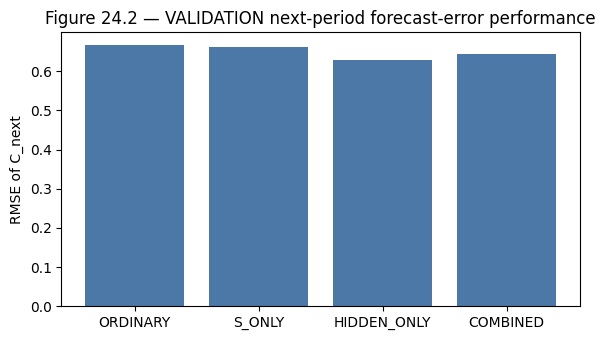

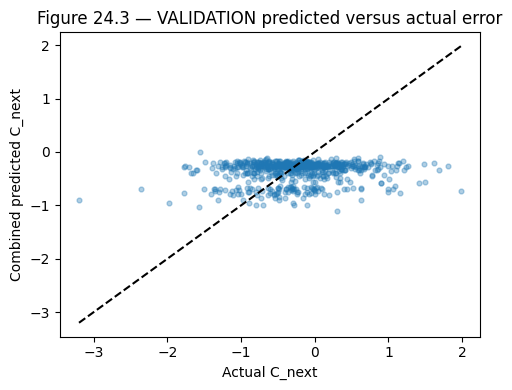

In [5]:
development_models = {}
validation_forecasts = validation_data[["model_day", "C_next", "G_next", "S_next", "hidden_type", "is_hidden"]].copy()
validation_forecasts["C_hat_ORDINARY"] = 0.0
for family, features in feature_sets.items():
    max_depth, min_leaf = selected_params[family]
    model = make_model(max_depth, min_leaf)
    model.fit(development_data[features], development_data["C_next"])
    development_models[family] = model
    validation_forecasts[f"C_hat_{family}"] = model.predict(validation_data[features])
    validation_forecasts[f"G_hat_{family}"] = -validation_data["S_next"].to_numpy() + validation_forecasts[f"C_hat_{family}"]
validation_forecasts["G_hat_ORDINARY"] = -validation_data["S_next"].to_numpy()

comparison_rows = []
for label, column in [("ORDINARY", "C_hat_ORDINARY"), ("S_ONLY", "C_hat_S_ONLY"), ("HIDDEN_ONLY", "C_hat_HIDDEN_ONLY"), ("COMBINED", "C_hat_COMBINED")]:
    prediction = validation_forecasts[column]
    prediction_correlation = (
        prediction.corr(validation_forecasts.C_next)
        if prediction.std(ddof=0) > 0
        else np.nan
    )
    comparison_rows.append({
        "model": label,
        "rmse": rmse(validation_forecasts.C_next, prediction),
        "mae": mae(validation_forecasts.C_next, prediction),
        "correlation": prediction_correlation,
    })
predictive_comparison = pd.DataFrame(comparison_rows)
ordinary_rmse = predictive_comparison.loc[predictive_comparison.model.eq("ORDINARY"), "rmse"].iloc[0]
s_rmse = predictive_comparison.loc[predictive_comparison.model.eq("S_ONLY"), "rmse"].iloc[0]
predictive_comparison["rmse_change_vs_ordinary"] = predictive_comparison.rmse - ordinary_rmse
predictive_comparison["rmse_change_vs_s_only"] = predictive_comparison.rmse - s_rmse
display(predictive_comparison.round(5))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(predictive_comparison.model, predictive_comparison.rmse, color="#4c78a8")
ax.set(title="Figure 24.2 — VALIDATION next-period forecast-error performance", ylabel="RMSE of C_next")
fig.tight_layout(); fig.savefig(FIGURES / "24_figure_validation_predictive_rmse.png", dpi=180); plt.show()
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(validation_forecasts.C_next, validation_forecasts.C_hat_COMBINED, alpha=.35, s=12)
limits = [min(validation_forecasts.C_next.min(), validation_forecasts.C_hat_COMBINED.min()), max(validation_forecasts.C_next.max(), validation_forecasts.C_hat_COMBINED.max())]
ax.plot(limits, limits, "k--"); ax.set(xlabel="Actual C_next", ylabel="Combined predicted C_next", title="Figure 24.3 — VALIDATION predicted versus actual error")
fig.tight_layout(); fig.savefig(FIGURES / "24_figure_validation_predicted_actual.png", dpi=180); plt.show()

# 8. Paired moving-block bootstrap

The bootstrap resamples paired, already-generated VALIDATION squared errors in chronological blocks. It does not refit a model. The estimand is \(\Delta RMSE=RMSE_{S+H}-RMSE_S\); a negative value favours the combined specification.

In [6]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
s_errors = (validation_forecasts.C_next - validation_forecasts.C_hat_S_ONLY).to_numpy()
combined_errors = (validation_forecasts.C_next - validation_forecasts.C_hat_COMBINED).to_numpy()
n_validation = len(s_errors)
starts = np.arange(n_validation - BLOCK_LENGTH + 1)
bootstrap_deltas = np.empty(BOOTSTRAP_REPS)
for replication in range(BOOTSTRAP_REPS):
    indices = []
    while len(indices) < n_validation:
        start = int(rng.choice(starts))
        indices.extend(range(start, start + BLOCK_LENGTH))
    indices = np.asarray(indices[:n_validation])
    bootstrap_deltas[replication] = np.sqrt(np.mean(combined_errors[indices] ** 2)) - np.sqrt(np.mean(s_errors[indices] ** 2))
observed_delta = rmse(validation_forecasts.C_next, validation_forecasts.C_hat_COMBINED) - rmse(validation_forecasts.C_next, validation_forecasts.C_hat_S_ONLY)
bootstrap_summary = pd.DataFrame([{"observed_delta_rmse": observed_delta, "bootstrap_mean": bootstrap_deltas.mean(), "p2_5": np.quantile(bootstrap_deltas, .025), "p97_5": np.quantile(bootstrap_deltas, .975), "fraction_combined_improves": np.mean(bootstrap_deltas < 0), "block_length": BLOCK_LENGTH, "reps": BOOTSTRAP_REPS, "seed": BOOTSTRAP_SEED}])
display(bootstrap_summary.round(6))

,observed_delta_rmse,bootstrap_mean,p2_5,p97_5,fraction_combined_improves,block_length,reps,seed
0,-0.018536,-0.0188,-0.028095,-0.009819,1.0,5,5000,24


# 9. Known-event target-day robustness audit

The primary sample excludes frozen known-primary events at model day \(t\), whereas the target is \(C_{t+1}\). This descriptive robustness audit explicitly joins known-event status on `next_model_day`, rather than shifting rows. It does not change hyperparameters, features, the primary result, or policy selection.

If the combined-minus-S robustness difference is negative, the qualitative incremental-information result survives this horizon exclusion; this sensitivity never replaces the primary analysis.

In [7]:
development_event_status = development_data[["model_day", "next_model_day"]].merge(
    known_event_lookup, on="next_model_day", how="left", validate="one_to_one"
)
development_event_status["is_known_primary_event_next"] = development_event_status["is_known_primary_event_next"].fillna(False).astype(bool)
validation_event_status = validation_data[["model_day", "next_model_day"]].merge(
    known_event_lookup, on="next_model_day", how="left", validate="one_to_one"
)
validation_event_status["is_known_primary_event_next"] = validation_event_status["is_known_primary_event_next"].fillna(False).astype(bool)
assert development_event_status.next_model_day.isin(known_event_lookup.next_model_day).all()
assert validation_event_status.next_model_day.isin(known_event_lookup.next_model_day).all()

validation_with_event_status = validation_forecasts.merge(
    validation_event_status[["model_day", "is_known_primary_event_next"]],
    on="model_day",
    how="left",
    validate="one_to_one",
)
validation_with_event_status["is_known_primary_event_next"] = validation_with_event_status["is_known_primary_event_next"].fillna(False).astype(bool)

development_robust = development_data.merge(
    development_event_status[["model_day", "is_known_primary_event_next"]], on="model_day", how="left", validate="one_to_one"
).loc[lambda frame: ~frame.is_known_primary_event_next].copy()
validation_robust = validation_data.merge(
    validation_event_status[["model_day", "is_known_primary_event_next"]], on="model_day", how="left", validate="one_to_one"
).loc[lambda frame: ~frame.is_known_primary_event_next].copy()
assert not development_robust.is_known_primary_event_pair.any()
assert not validation_robust.is_known_primary_event_pair.any()
assert not development_robust.is_known_primary_event_next.any()
assert not validation_robust.is_known_primary_event_next.any()

robustness_rows = []
robust_predictions = {"ORDINARY": np.zeros(len(validation_robust))}
for family, features in feature_sets.items():
    max_depth, min_leaf = selected_params[family]
    robust_model = make_model(max_depth, min_leaf)
    robust_model.fit(development_robust[features], development_robust.C_next)
    robust_predictions[family] = robust_model.predict(validation_robust[features])
for label, prediction in robust_predictions.items():
    robustness_rows.append({
        "sample": "t_and_t_plus_1_known_event_excluded_refit",
        "model": label,
        "n_development": len(development_robust),
        "n_validation": len(validation_robust),
        "rmse": rmse(validation_robust.C_next, prediction),
        "mae": mae(validation_robust.C_next, prediction),
    })
known_event_predictive_sensitivity = pd.DataFrame(robustness_rows)
robust_s_rmse = known_event_predictive_sensitivity.loc[known_event_predictive_sensitivity.model.eq("S_ONLY"), "rmse"].iloc[0]
known_event_predictive_sensitivity["combined_minus_s_rmse"] = known_event_predictive_sensitivity.rmse - robust_s_rmse
display(known_event_predictive_sensitivity.round(6))

,sample,model,n_development,n_validation,rmse,mae,combined_minus_s_rmse
0,t_and_t_plus_1_known_event_excluded_refit,ORDINARY,417,478,0.644409,0.508346,-0.001711
1,t_and_t_plus_1_known_event_excluded_refit,S_ONLY,417,478,0.646120,0.501582,0.000000
2,t_and_t_plus_1_known_event_excluded_refit,HIDDEN_ONLY,417,478,0.596793,0.464422,-0.049327
3,t_and_t_plus_1_known_event_excluded_refit,COMBINED,417,478,0.618997,0.478642,-0.027123


# 10. Economic hidden-event handoff

The hidden state is the economic gate: only hidden VALIDATION states with a complete N23 contract enter this economic universe. It tells the application **when** the ordinary system is abnormal. The combined GB forecast determines **direction**:

$$\widehat G_{t+1}^{GB}=-S_{t+1}+\widehat C_{t+1}^{S+H}.$$ 

Positive values select a long straddle, negative values a short straddle, and zero a flat decision. Gradient Boosting minimises squared-error regression loss internally; the episode-level risk-weighted PnL score \(J=\bar r/s(r)\) selects only the resulting GB-driven economic decision rule.

In [8]:
economic_data = validation_with_event_status.merge(n23, on="model_day", how="left", suffixes=("", "_n23"), validate="one_to_one")
hidden_validation = economic_data.loc[economic_data.hidden_type.isin(["REALISED_ONLY", "IMPLIED_ONLY"])].copy()
hidden_validation["economic_complete"] = hidden_validation.contract_complete.eq(True) & hidden_validation.pnl_unlocked.eq(True)
economic_episodes = hidden_validation.loc[hidden_validation.economic_complete].copy()
assert economic_episodes[["long_pnl_bidask", "short_pnl_bidask", "spot_entry_mid", "G_hat_COMBINED", "G_hat_S_ONLY"]].apply(np.isfinite).all().all()
economic_coverage = pd.DataFrame([{"total_validation_hidden_states": len(hidden_validation), "forecast_available": len(hidden_validation), "complete_n23_contract": int(hidden_validation.economic_complete.sum()), "economically_evaluable": len(economic_episodes), "known_event_at_t_plus_1": int(economic_episodes.is_known_primary_event_next.sum()), "without_known_event_at_t_plus_1": int((~economic_episodes.is_known_primary_event_next).sum()), "excluded": int((~hidden_validation.economic_complete).sum())}])
display(economic_coverage)

magnitudes = economic_episodes.G_hat_COMBINED.abs()
thresholds = sorted(set(float(magnitudes.quantile(q)) for q in [.25, .5, .75]))
policy_definitions = pd.DataFrame([
    ("FLAT", "benchmark", "hidden gate", "0", False, False),
    ("ALWAYS_LONG", "benchmark", "hidden gate", "+1", False, False),
    ("ALWAYS_SHORT", "benchmark", "hidden gate", "-1", False, False),
    ("TYPE_ONLY", "benchmark", "hidden type", "legacy type direction", True, False),
    ("ORDINARY_ONLY", "benchmark", "hidden gate + ordinary signal", "sign(-S_next)", False, False),
    ("GB_S_ONLY", "benchmark", "hidden gate + S-only GB", "sign(G_hat_GB_S)", False, False),
    ("ML_SIGN", "final candidate", "hidden gate + combined GB", "sign(G_hat_GB)", False, True),
    ("ML_THRESHOLD", "final candidate", "hidden gate + combined GB", "sign(G_hat_GB) if abs(G_hat_GB)>=tau", False, True),
], columns=["policy", "policy_class", "information", "action_rule", "uses_hidden_type_direction", "uses_combined_gb"])
display(policy_definitions)


policy_metadata_semantics = pd.DataFrame([
    ("FLAT", False, False, True, False, False),
    ("ALWAYS_LONG", False, False, True, False, False),
    ("ALWAYS_SHORT", False, False, True, False, False),
    ("TYPE_ONLY", False, False, True, True, False),
    ("ORDINARY_ONLY", False, False, True, False, False),
    ("GB_S_ONLY", True, False, True, False, False),
    ("ML_SIGN", True, True, True, False, True),
    ("ML_THRESHOLD", True, True, True, False, True),
], columns=["policy", "uses_gb", "uses_combined_hidden_state", "uses_hidden_gate", "uses_hidden_type_direction", "final_policy_eligible"])
display(policy_metadata_semantics)


,total_validation_hidden_states,forecast_available,complete_n23_contract,economically_evaluable,known_event_at_t_plus_1,without_known_event_at_t_plus_1,excluded
0,12,12,10,10,0,10,2


,policy,policy_class,information,action_rule,uses_hidden_type_direction,uses_combined_gb
0,FLAT,benchmark,hidden gate,0,False,False
1,ALWAYS_LONG,benchmark,hidden gate,+1,False,False
2,ALWAYS_SHORT,benchmark,hidden gate,-1,False,False
3,TYPE_ONLY,benchmark,hidden type,legacy type direction,True,False
4,ORDINARY_ONLY,benchmark,hidden gate + ordinary signal,sign(-S_next),False,False
5,GB_S_ONLY,benchmark,hidden gate + S-only GB,sign(G_hat_GB_S),False,False
6,ML_SIGN,final candidate,hidden gate + combined GB,sign(G_hat_GB),False,True
7,ML_THRESHOLD,final candidate,hidden gate + combined GB,sign(G_hat_GB) if abs(G_hat_GB)>=tau,False,True


,policy,uses_gb,uses_combined_hidden_state,uses_hidden_gate,uses_hidden_type_direction,final_policy_eligible
0,FLAT,False,False,True,False,False
1,ALWAYS_LONG,False,False,True,False,False
2,ALWAYS_SHORT,False,False,True,False,False
3,TYPE_ONLY,False,False,True,True,False
4,ORDINARY_ONLY,False,False,True,False,False
5,GB_S_ONLY,True,False,True,False,False
6,ML_SIGN,True,True,True,False,True
7,ML_THRESHOLD,True,True,True,False,True


# 11. GB-driven policy design

Hidden status is the trade gate. The combined GB forecast determines long/short direction, and OOS signal magnitude supplies the common threshold candidates. TYPE_ONLY is a benchmark directional hypothesis only.

In [9]:
def actions_for_policy(frame, policy, threshold=None):
    if policy == "FLAT":
        return np.zeros(len(frame), dtype=int)
    if policy == "ALWAYS_LONG":
        return np.ones(len(frame), dtype=int)
    if policy == "ALWAYS_SHORT":
        return -np.ones(len(frame), dtype=int)
    if policy == "TYPE_ONLY":
        return np.where(frame.hidden_type.eq("REALISED_ONLY"), 1, -1)
    if policy == "ORDINARY_ONLY":
        return np.sign(-frame.S_next).astype(int).to_numpy()
    if policy == "GB_S_ONLY":
        return np.sign(frame.G_hat_S_ONLY).astype(int).to_numpy()
    if policy == "ML_SIGN":
        return np.sign(frame.G_hat_COMBINED).astype(int).to_numpy()
    if policy == "ML_THRESHOLD":
        magnitude_is_large = frame.G_hat_COMBINED.abs().ge(float(threshold))
        return np.where(magnitude_is_large, np.sign(frame.G_hat_COMBINED), 0).astype(int)
    raise ValueError(policy)

def policy_metrics(frame, policy, threshold=None):
    actions = actions_for_policy(frame, policy, threshold)
    pnl = np.where(actions > 0, frame.long_pnl_bidask, np.where(actions < 0, frame.short_pnl_bidask, 0.0))
    returns = pnl / frame.spot_entry_mid.to_numpy()
    n_trades = int(np.count_nonzero(actions))
    standard_deviation = float(np.std(returns, ddof=1)) if len(returns) > 1 else np.nan
    score = float(np.mean(returns) / standard_deviation) if np.isfinite(standard_deviation) and standard_deviation > 0 else np.nan
    final_candidate = policy in {"ML_SIGN", "ML_THRESHOLD"}
    eligible = final_candidate and n_trades >= MINIMUM_TRADES and np.mean(returns) > 0 and np.isfinite(score) and score > 0
    return {"policy": policy, "policy_class": "final_candidate" if final_candidate else "benchmark", "uses_hidden_gate": True, "uses_combined_gb": policy in {"ML_SIGN", "ML_THRESHOLD"}, "threshold": threshold, "n_episodes": len(frame), "n_trades": n_trades, "long_trades": int((actions > 0).sum()), "short_trades": int((actions < 0).sum()), "flat": int((actions == 0).sum()), "total_raw_jpy_pnl": float(np.sum(pnl)), "mean_raw_jpy_pnl": float(np.mean(pnl)), "mean_spot_normalised_return": float(np.mean(returns)), "median_spot_normalised_return": float(np.median(returns)), "std_spot_normalised_return": standard_deviation, "J": score, "win_rate": float(np.mean(returns[actions != 0] > 0)) if n_trades else np.nan, "worst_episode_return": float(np.min(returns)), "eligible_final_policy": eligible, "actions": actions, "pnl": pnl, "returns": returns}

policy_results = [policy_metrics(economic_episodes, policy) for policy in ["FLAT", "ALWAYS_LONG", "ALWAYS_SHORT", "TYPE_ONLY", "ORDINARY_ONLY", "GB_S_ONLY", "ML_SIGN"]]
policy_results.extend(policy_metrics(economic_episodes, "ML_THRESHOLD", threshold) for threshold in thresholds)
policy_comparison = pd.DataFrame([{key: value for key, value in result.items() if key not in {"actions", "pnl", "returns"}} for result in policy_results])
eligible_policies = policy_comparison.loc[policy_comparison.eligible_final_policy].copy()
if eligible_policies.empty:
    final_policy = "FLAT"
    final_threshold = np.nan
    flat_fallback = True
else:
    eligible_policies["complexity"] = np.where(eligible_policies.policy.eq("ML_SIGN"), 0, 1)
    eligible_policies = eligible_policies.sort_values(["J", "complexity", "threshold"], ascending=[False, True, True])
    selected = eligible_policies.iloc[0]
    final_policy = selected.policy
    final_threshold = selected.threshold
    flat_fallback = False
policy_comparison["selected_final_policy"] = policy_comparison.policy.eq(final_policy) & (policy_comparison.threshold.eq(final_threshold) | (policy_comparison.threshold.isna() & pd.isna(final_threshold)))
display(policy_comparison.round(6))


,policy,policy_class,uses_hidden_gate,uses_combined_gb,threshold,n_episodes,n_trades,long_trades,short_trades,flat,total_raw_jpy_pnl,mean_raw_jpy_pnl,mean_spot_normalised_return,median_spot_normalised_return,std_spot_normalised_return,J,win_rate,worst_episode_return,eligible_final_policy,selected_final_policy
0,FLAT,benchmark,True,False,NaN,10,0,0,0,10,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,False,True
1,ALWAYS_LONG,benchmark,True,False,NaN,10,10,10,0,0,0.114660,0.011466,0.000102,0.000115,0.000496,0.205732,0.600000,-0.000700,False,False
2,ALWAYS_SHORT,benchmark,True,False,NaN,10,10,0,10,0,-0.430419,-0.043042,-0.000390,-0.000494,0.000521,-0.748574,0.300000,-0.001252,False,False
3,TYPE_ONLY,benchmark,True,False,NaN,10,10,7,3,0,0.005902,0.000590,0.000006,0.000014,0.000530,0.011123,0.500000,-0.000700,False,False
4,ORDINARY_ONLY,benchmark,True,False,NaN,10,10,5,5,0,-0.056529,-0.005653,-0.000050,-0.000217,0.000553,-0.089654,0.400000,-0.000674,False,False
5,GB_S_ONLY,benchmark,True,False,NaN,10,10,0,10,0,-0.430419,-0.043042,-0.000390,-0.000494,0.000521,-0.748574,0.300000,-0.001252,False,False
6,ML_SIGN,final_candidate,True,True,NaN,10,10,1,9,0,-0.301653,-0.030165,-0.000272,-0.000301,0.000560,-0.486653,0.400000,-0.001252,False,False
7,ML_THRESHOLD,final_candidate,True,True,0.234690,10,7,0,7,3,-0.414838,-0.041484,-0.000377,-0.000301,0.000431,-0.874814,0.142857,-0.001252,False,False
8,ML_THRESHOLD,final_candidate,True,True,0.268255,10,5,0,5,5,-0.321742,-0.032174,-0.000292,0.000000,0.000441,-0.660992,0.200000,-0.001252,False,False
9,ML_THRESHOLD,final_candidate,True,True,0.434648,10,3,0,3,7,-0.104102,-0.010410,-0.000093,0.000000,0.000215,-0.435162,0.333333,-0.000564,False,False


# 12. VALIDATION risk-weighted GB-policy selection

TYPE_ONLY, ordinary-only, and S-only GB rules are descriptive benchmarks. They cannot be final policies. The final candidate set is only ML_SIGN and the three OOS-signal-magnitude ML_THRESHOLD candidates. The hidden detector gates the trade universe, while the sign and magnitude of the combined GB forecast select direction and abstention. PnL does not enter the threshold grid; it only compares the pre-specified candidates by \(J\).

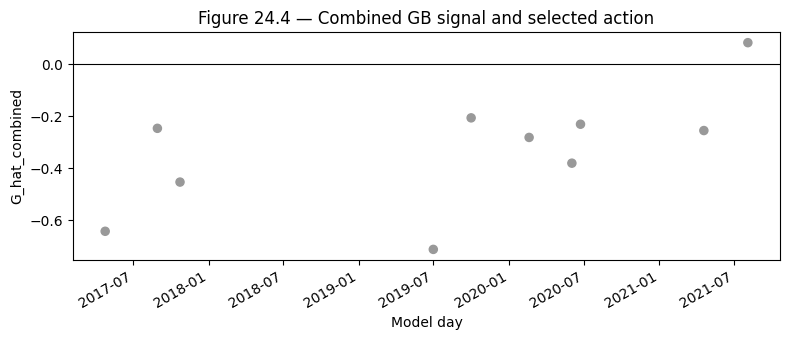

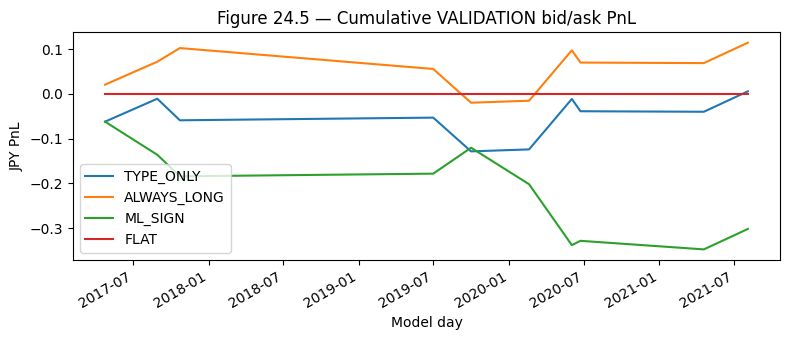

In [10]:
selected_result = next(
    result for result in policy_results
    if result["policy"] == final_policy
    and (pd.isna(final_threshold) or result["threshold"] == final_threshold)
)
economic_episodes["selected_action"] = selected_result["actions"]
economic_episodes["selected_pnl"] = selected_result["pnl"]

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = np.where(economic_episodes.selected_action.eq(1), "#4c78a8", np.where(economic_episodes.selected_action.eq(-1), "#e45756", "#999999"))
ax.scatter(economic_episodes.model_day, economic_episodes.G_hat_COMBINED, c=colors, s=34)
ax.axhline(0, color="black", linewidth=.8)
ax.set(title="Figure 24.4 — Combined GB signal and selected action", xlabel="Model day", ylabel="G_hat_combined")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "24_figure_validation_gb_signal_action.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_policy_names = list(dict.fromkeys(["TYPE_ONLY", "ALWAYS_LONG", "ML_SIGN", final_policy]))
for name in plot_policy_names:
    result = next(
        item for item in policy_results
        if item["policy"] == name
        and (name != "ML_THRESHOLD" or item["threshold"] == final_threshold)
    )
    ax.plot(economic_episodes.model_day, np.cumsum(result["pnl"]), label=name)
ax.set(title="Figure 24.5 — Cumulative VALIDATION bid/ask PnL", xlabel="Model day", ylabel="JPY PnL")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "24_figure_validation_cumulative_pnl.png", dpi=180)
plt.show()

# 13. Economic known-event-horizon audit

The economic hidden-event sample reports the count with and without a known event at t+1. It is descriptive only and cannot alter the frozen policy.

# 14. Final pre-TEST model refit and frozen artifacts

All statistical and economic choices are now frozen. The three selected specifications are refitted once on DEVELOPMENT plus VALIDATION under the same eligibility definition. The validation-selected policy architecture and, if applicable, exact threshold are retained without re-optimisation.

In [11]:
pretest_data = common_sample.copy()
assert pretest_data.application_stage.isin(["DEVELOPMENT", "VALIDATION"]).all()
assert not pretest_data.model_day.isin(test_locked_audit.model_day).any()
frozen_models = {}
specification_rows = []
for family, features in feature_sets.items():
    max_depth, min_leaf = selected_params[family]
    model = make_model(max_depth, min_leaf)
    model.fit(pretest_data[features], pretest_data.C_next)
    artifact = PROCESSED / f"24_frozen_gb_{family.lower()}.joblib"
    joblib.dump(model, artifact)
    checksum = hashlib.sha256(artifact.read_bytes()).hexdigest()
    frozen_models[family] = model
    specification_rows.append({"model_family": "GradientBoostingRegressor", "target": "C_next", "feature_family": family, "feature_names": json.dumps(features), "max_depth": max_depth, "min_samples_leaf": min_leaf, "n_estimators": N_ESTIMATORS, "learning_rate": LEARNING_RATE, "loss": LOSS, "random_state": RANDOM_STATE, "cv_scheme": "TimeSeriesSplit(n_splits=4), DEVELOPMENT only", "development_sample_size": len(development_data), "final_pretest_refit_sample_size": len(pretest_data), "model_artifact_path": (Path("Data") / "processed" / artifact.name).as_posix(), "sha256": checksum, "frozen": True})
frozen_model_specification = pd.DataFrame(specification_rows)
policy_specification = pd.DataFrame([{"final_policy": final_policy, "gb_driven_candidate_qualified": bool(policy_comparison.eligible_final_policy.any()), "policy_selected_on": "VALIDATION", "policy_class": "GB_DRIVEN" if final_policy != "FLAT" else "FLAT_FALLBACK", "hidden_state_used_as_gate": True, "gb_model_family": "GradientBoostingRegressor", "gb_feature_family": "COMBINED", "gb_features": json.dumps(feature_sets["COMBINED"]), "action_space": "{-1,0,+1}", "combined_forecast_definition": "-S_next + C_hat_COMBINED", "signal_direction_rule": "sign(G_hat_COMBINED)", "threshold": final_threshold, "threshold_origin": "VALIDATION OOS magnitude quantile grid" if final_policy == "ML_THRESHOLD" else "NOT_APPLICABLE", "fixed_position_size": "one synthetic straddle", "underlying_option_notional": "1 USD", "primary_pnl_field": "N23 bid/ask-adjusted long/short PnL", "economic_normalisation": "PnL / spot_entry_mid", "risk_weighted_objective": "mean return / sample standard deviation; not annualised", "minimum_trade_count": MINIMUM_TRADES, "threshold_grid_definition": "Q25/Q50/Q75 of |G_hat_COMBINED| on economically evaluable hidden VALIDATION episodes", "policy_eligibility": "n_trades>=4; mean return>0; J>0", "benchmark_only_policies": "FLAT; ALWAYS_LONG; ALWAYS_SHORT; TYPE_ONLY; ORDINARY_ONLY; GB_S_ONLY", "development_period": "frozen N22 DEVELOPMENT", "validation_period": "frozen N22 VALIDATION", "test_used_in_selection": False, "policy_frozen": True}])
display(frozen_model_specification)
display(policy_specification)

,model_family,target,feature_family,feature_names,max_depth,min_samples_leaf,n_estimators,learning_rate,loss,random_state,cv_scheme,development_sample_size,final_pretest_refit_sample_size,model_artifact_path,sha256,frozen
0,GradientBoostingRegressor,C_next,S_ONLY,"[""S_next""]",1,20,100,0.05,squared_error,24,"TimeSeriesSplit(n_splits=4), DEVELOPMENT only",579,1236,Data/processed/24_frozen_gb_s_only.joblib,457f7a4efeeb4fee7102b10ed5c19e75376c63a663a4f0...,True
1,GradientBoostingRegressor,C_next,HIDDEN_ONLY,"[""D"", ""Z_R"", ""Z_I_prev""]",1,20,100,0.05,squared_error,24,"TimeSeriesSplit(n_splits=4), DEVELOPMENT only",579,1236,Data/processed/24_frozen_gb_hidden_only.joblib,190d58430b4b694113fe75c4d2f4a528fe70fd2047d45c...,True
2,GradientBoostingRegressor,C_next,COMBINED,"[""S_next"", ""D"", ""Z_R"", ""Z_I_prev""]",1,20,100,0.05,squared_error,24,"TimeSeriesSplit(n_splits=4), DEVELOPMENT only",579,1236,Data/processed/24_frozen_gb_combined.joblib,62e630bbd3d8c8c6d22b17d2dbe02f4c12215563864371...,True


,final_policy,gb_driven_candidate_qualified,policy_selected_on,policy_class,hidden_state_used_as_gate,gb_model_family,gb_feature_family,gb_features,action_space,combined_forecast_definition,...,economic_normalisation,risk_weighted_objective,minimum_trade_count,threshold_grid_definition,policy_eligibility,benchmark_only_policies,development_period,validation_period,test_used_in_selection,policy_frozen
0,FLAT,False,VALIDATION,FLAT_FALLBACK,True,GradientBoostingRegressor,COMBINED,"[""S_next"", ""D"", ""Z_R"", ""Z_I_prev""]","{-1,0,+1}",-S_next + C_hat_COMBINED,...,PnL / spot_entry_mid,mean return / sample standard deviation; not a...,4,Q25/Q50/Q75 of |G_hat_COMBINED| on economicall...,n_trades>=4; mean return>0; J>0,FLAT; ALWAYS_LONG; ALWAYS_SHORT; TYPE_ONLY; OR...,frozen N22 DEVELOPMENT,frozen N22 VALIDATION,False,True


# 15. Frozen application specification

The final pre-TEST model specification is refit on the frozen pre-TEST support. This mechanical hand-off does not inspect or evaluate TEST outcomes.


# 16. Limitations and interpretation

The statistical result is predictive, not structural intervention. GB forecasts an ordinary-model residual, not option mispricing or a causal effect. The hidden detector identifies an unusual application state; the combined GB forecast supplies conditional direction. Squared-error loss is the internal regression fitting loss, whereas risk-weighted synthetic PnL is the application-level policy objective. The hidden economic sample is small and the threshold family is deliberately low-capacity. N23 PnL is synthetic; observed spot hedge bid/ask is included but historical option bid/ask is unavailable. Statistical improvement need not imply an economically eligible policy. TEST remains untouched.

# 17. Closure and exports

Every result below is computed from the executed objects before export.

In [12]:
primary_reference = {
    "development_n": 579, "validation_n": 657,
    "ordinary_rmse": 0.6656972917977443, "ordinary_mae": 0.5206292135101526,
    "s_rmse": 0.6617083853934335, "s_mae": 0.5097266405909865,
    "hidden_rmse": 0.6275488146099817, "hidden_mae": 0.4833555357979699,
    "combined_rmse": 0.6431728391905629, "combined_mae": 0.49632934351735364,
    "combined_minus_s": -0.0185355462028705,
    "bootstrap_low": -0.028095020612364165, "bootstrap_high": -0.009818733760638486,
    "bootstrap_fraction": 1.0,
    "thresholds": [0.23468983650018221, 0.2682547839622752, 0.434647513702269],
    "type_only_j": 0.011123203354875362,
    "always_long_j": 0.20573189392520563,
    "ml_sign_j": -0.4866530756293799,
    "ml_threshold_j": [-0.8748137656691085, -0.6609919987050783, -0.43516151528167507],
    "model_hashes": [
        "457f7a4efeeb4fee7102b10ed5c19e75376c63a663a4f02297031ac03b47c58e",
        "190d58430b4b694113fe75c4d2f4a528fe70fd2047d45c10b6e3dcdde6a325b7",
        "62e630bbd3d8c8c6d22b17d2dbe02f4c122155638643710e5a05ecce0e6fd69e",
    ],
}
check_test_g_locked = test_locked_audit.G_next.isna().all()
check_test_c_locked = test_locked_audit.C_next.isna().all()
check_test_pnl_locked = test_pnl_audit[["long_pnl_bidask", "short_pnl_bidask", "terminal_spot"]].isna().all().all() and test_pnl_audit.pnl_unlocked.eq(False).all()
check_no_test_in_training = not development_data.model_day.isin(test_locked_audit.model_day).any() and not pretest_data.model_day.isin(test_locked_audit.model_day).any()
check_no_test_in_validation_selection = not validation_data.model_day.isin(test_locked_audit.model_day).any()
check_no_test_in_policy_selection = not economic_episodes.model_day.isin(test_locked_audit.model_day).any()
check_development_only_hyperparameter_tuning = len(cv_results) == 12 and TSCV_SPLITS == 4
check_four_gb_candidates_per_family = cv_results.groupby("feature_family").size().eq(4).all()
check_four_chronological_folds = TSCV_SPLITS == 4
check_no_shuffle = isinstance(splitter, TimeSeriesSplit)
check_s_feature_set = feature_sets["S_ONLY"] == ["S_next"]
check_h_feature_set = feature_sets["HIDDEN_ONLY"] == ["D", "Z_R", "Z_I_prev"]
check_combined_feature_set = feature_sets["COMBINED"] == ["S_next", "D", "Z_R", "Z_I_prev"]
check_threshold_candidates_unchanged = np.allclose(thresholds, primary_reference["thresholds"])
policy_j_by_name = policy_comparison.groupby("policy")["J"].first()
threshold_policy_j = policy_comparison.loc[policy_comparison.policy.eq("ML_THRESHOLD"), "J"].tolist()
check_policy_comparison_unchanged = bool(
    np.isclose(policy_j_by_name["TYPE_ONLY"], primary_reference["type_only_j"])
    and np.isclose(policy_j_by_name["ALWAYS_LONG"], primary_reference["always_long_j"])
    and np.isclose(policy_j_by_name["ML_SIGN"], primary_reference["ml_sign_j"])
    and np.allclose(threshold_policy_j, primary_reference["ml_threshold_j"])
    and final_policy == "FLAT"
)
check_model_hashes_unchanged = frozen_model_specification.sha256.tolist() == primary_reference["model_hashes"]
check_primary_stats_unchanged = (
    len(development_data) == primary_reference["development_n"] and len(validation_data) == primary_reference["validation_n"]
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("ORDINARY"), "rmse"].iloc[0], primary_reference["ordinary_rmse"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("ORDINARY"), "mae"].iloc[0], primary_reference["ordinary_mae"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("S_ONLY"), "rmse"].iloc[0], primary_reference["s_rmse"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("S_ONLY"), "mae"].iloc[0], primary_reference["s_mae"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("HIDDEN_ONLY"), "rmse"].iloc[0], primary_reference["hidden_rmse"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("HIDDEN_ONLY"), "mae"].iloc[0], primary_reference["hidden_mae"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("COMBINED"), "rmse"].iloc[0], primary_reference["combined_rmse"])
    and np.isclose(predictive_comparison.loc[predictive_comparison.model.eq("COMBINED"), "mae"].iloc[0], primary_reference["combined_mae"])
    and selected_params == {"S_ONLY": (1, 20), "HIDDEN_ONLY": (1, 20), "COMBINED": (1, 20)}
    and np.isclose(observed_delta, primary_reference["combined_minus_s"])
    and np.isclose(bootstrap_summary.p2_5.iloc[0], primary_reference["bootstrap_low"])
    and np.isclose(bootstrap_summary.p97_5.iloc[0], primary_reference["bootstrap_high"])
    and np.isclose(bootstrap_summary.fraction_combined_improves.iloc[0], primary_reference["bootstrap_fraction"])
    and check_threshold_candidates_unchanged
    and check_policy_comparison_unchanged
    and check_model_hashes_unchanged
)
check_bootstrap_config = BLOCK_LENGTH == 5 and BOOTSTRAP_REPS == 5000 and BOOTSTRAP_SEED == 24
check_known_event_next_exact_join = development_event_status.next_model_day.isin(known_event_lookup.next_model_day).all() and validation_event_status.next_model_day.isin(known_event_lookup.next_model_day).all()
check_known_event_count_logic = (known_event_target_day_audit.known_at_either + known_event_target_day_audit.known_at_neither == known_event_target_day_audit.total_common_rows_before_known_event_exclusion).all()
check_robustness_hyperparameters_frozen = set(selected_params) == set(feature_sets) and len(development_robust) > 0 and len(validation_robust) > 0
check_type_only_benchmark_only = not policy_comparison.loc[policy_comparison.policy.eq("TYPE_ONLY"), "selected_final_policy"].any()
check_final_candidate_family = set(policy_comparison.loc[policy_comparison.eligible_final_policy, "policy"]).issubset({"ML_SIGN", "ML_THRESHOLD"}) and final_policy in {"FLAT", "ML_SIGN", "ML_THRESHOLD"}
check_policy_uses_bidask_pnl = "bid/ask" in policy_specification.primary_pnl_field.iloc[0].lower()
check_threshold_grid_no_pnl = thresholds == sorted(set(float(economic_episodes.G_hat_COMBINED.abs().quantile(q)) for q in [.25, .5, .75]))
check_selected_policy_valid_or_flat = flat_fallback or policy_comparison.loc[policy_comparison.selected_final_policy, "eligible_final_policy"].all()
check_final_refit_pretest_only = pretest_data.application_stage.isin(["DEVELOPMENT", "VALIDATION"]).all()
model_paths = [PROCESSED / "24_frozen_gb_s_only.joblib", PROCESSED / "24_frozen_gb_hidden_only.joblib", PROCESSED / "24_frozen_gb_combined.joblib"]
check_model_artifacts_exist = all(path.exists() for path in model_paths)
check_model_hashes_exist = frozen_model_specification.sha256.str.len().eq(64).all()
check_model_hashes_unchanged = frozen_model_specification.sha256.tolist() == primary_reference["model_hashes"]
check_policy_artifact_exists = (PROCESSED / "24_frozen_policy_specification.csv").exists()
check_test_used_in_selection_false = policy_specification.test_used_in_selection.eq(False).all()
check_no_test_hedge_ledger = test_pnl_audit[["long_pnl_bidask", "short_pnl_bidask"]].isna().all().all()
check_project_relative_paths = frozen_model_specification.model_artifact_path.str.startswith("Data/processed/").all()
ordinary_correlation_is_undefined = predictive_comparison.loc[
    predictive_comparison["model"].eq("ORDINARY"), "correlation"
].isna().all()
nonordinary_correlations_are_finite = np.isfinite(
    predictive_comparison.loc[
        ~predictive_comparison["model"].eq("ORDINARY"), "correlation"
    ]
).all()
check_warnings_none = len(execution_warning_log) == 0
closure_checks = {
    "Primary N24 statistical results unchanged": check_primary_stats_unchanged,
    "GB remains primary non-parametric learner": all(isinstance(model, GradientBoostingRegressor) for model in frozen_models.values()),
    "DEVELOPMENT-only hyperparameter tuning": check_development_only_hyperparameter_tuning,
    "VALIDATION genuinely OOS": check_no_test_in_validation_selection,
    "S vs S+H incremental test preserved": np.isclose(observed_delta, primary_reference["combined_minus_s"]),
    "5-day moving-block bootstrap preserved": check_bootstrap_config,
    "Known-event t/t+1 audit uses row-wise logic": check_known_event_count_logic,
    "Known-event next-day join exact": check_known_event_next_exact_join,
    "Robustness refit uses frozen hyperparameters": check_robustness_hyperparameters_frozen,
    "TYPE_ONLY benchmark only": check_type_only_benchmark_only,
    "Final candidate family GB-driven only": check_final_candidate_family,
    "Risk-weighted PnL remains application objective": check_policy_uses_bidask_pnl,
    "Final policy frozen": policy_specification.policy_frozen.eq(True).all(),
    "Project-relative model paths used": check_project_relative_paths,
    "Model artifacts exist": check_model_artifacts_exist,
    "SHA256 hashes exist": check_model_hashes_exist,
    "TEST targets locked": check_test_g_locked and check_test_c_locked,
    "TEST PnL locked": check_test_pnl_locked,
    "No TEST rows used in fitting or selection": check_no_test_in_training and check_no_test_in_validation_selection and check_no_test_in_policy_selection,
    "No TEST hedge ledger": check_no_test_hedge_ledger,
    "Notebook warnings": check_warnings_none,
}
closure = pd.DataFrame({"check": list(closure_checks), "result": list(closure_checks.values())})
display(closure)
print("closure false checks:", [name for name, value in closure_checks.items() if not value])
assert all(closure_checks.values())

exports = {
    "24_development_cv_results.csv": cv_results,
    "24_validation_predictive_comparison.csv": predictive_comparison,
    "24_validation_forecasts.csv": validation_forecasts,
    "24_validation_incremental_bootstrap.csv": pd.DataFrame({"delta_rmse": bootstrap_deltas}),
    "24_validation_policy_comparison.csv": policy_comparison,
    "24_known_event_target_day_audit.csv": known_event_target_day_audit,
    "24_known_event_predictive_sensitivity.csv": known_event_predictive_sensitivity,
    "24_frozen_model_specification.csv": frozen_model_specification,
    "24_frozen_policy_specification.csv": policy_specification,
    "24_run_metadata.csv": pd.DataFrame([{"notebook": "24_application_nonparametric_signal_and_economic_validation.ipynb", "timestamp_utc": datetime.now(timezone.utc).isoformat(), "test_used": False, "test_locked": True, "primary_learner": "GradientBoostingRegressor", "policy_selected_on": "VALIDATION"}]),
}
for filename, frame in exports.items():
    temporary = PROCESSED / f".{filename}.tmp"
    frame.to_csv(temporary, index=False)
    temporary.replace(PROCESSED / filename)
print("N24 closure: PASS")

,check,result
0,Primary N24 statistical results unchanged,True
1,GB remains primary non-parametric learner,True
2,DEVELOPMENT-only hyperparameter tuning,True
3,VALIDATION genuinely OOS,True
4,S vs S+H incremental test preserved,True
5,5-day moving-block bootstrap preserved,True
6,Known-event t/t+1 audit uses row-wise logic,True
7,Known-event next-day join exact,True
8,Robustness refit uses frozen hyperparameters,True
9,TYPE_ONLY benchmark only,True


closure false checks: []
N24 closure: PASS
